# LSS vs all-MiniLM-L6-v2

Compare our custom embedding model against the reference MiniLM model.

In [1]:
import sys
sys.path.insert(0, '..')

import logging
logging.basicConfig(level=logging.INFO, format='%(message)s')

from benchmarks.compare import compare

results = compare()

loading MiniLM-L6-v2...
HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d2e6f8de32d1f16199bf/config.json "HTTP/1.1 200 OK"
HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d2e6f8de32d1f16199bf/tokenizer_config.json "HTTP/1.1 200 OK"
HTTP Request: GET https://huggingface.co/api/models/sentence-transformers/all-MiniLM-L6-v2/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
HTTP Request: GET https://huggingface.co/api/models/sentence-transformers/all-MiniLM-L6-v2/tree/main?recursive=true&expand=false "HTTP/1.1 20

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

loading LSS model...
HTTP Request: HEAD https://huggingface.co/bert-base-uncased/resolve/main/config.json "HTTP/1.1 200 OK"
HTTP Request: HEAD https://huggingface.co/bert-base-uncased/resolve/main/tokenizer_config.json "HTTP/1.1 200 OK"
HTTP Request: GET https://huggingface.co/api/models/bert-base-uncased/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 307 Temporary Redirect"
HTTP Request: GET https://huggingface.co/api/models/google-bert/bert-base-uncased/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
HTTP Request: GET https://huggingface.co/api/models/bert-base-uncased/tree/main?recursive=true&expand=false "HTTP/1.1 307 Temporary Redirect"
HTTP Request: GET https://huggingface.co/api/models/google-bert/bert-base-uncased/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"
loading STS-B validation set...
HTTP Request: HEAD https://huggingface.co/datasets/SetFit/stsb/resolve/main/README.md "HTTP/1.1 307 Temporary 

HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d2e6f8de32d1f16199bf/config.json "HTTP/1.1 200 OK"
HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d2e6f8de32d1f16199bf/tokenizer_config.json "HTTP/1.1 200 OK"
HTTP Request: GET https://huggingface.co/api/models/sentence-transformers/all-MiniLM-L6-v2/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
HTTP Request: GET https://huggingface.co/api/models/sentence-transformers/all-MiniLM-L6-v2/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"
HTTP Request: HEAD

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

HTTP Request: HEAD https://huggingface.co/bert-base-uncased/resolve/main/config.json "HTTP/1.1 200 OK"
HTTP Request: HEAD https://huggingface.co/bert-base-uncased/resolve/main/tokenizer_config.json "HTTP/1.1 200 OK"
HTTP Request: GET https://huggingface.co/api/models/bert-base-uncased/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 307 Temporary Redirect"
HTTP Request: GET https://huggingface.co/api/models/google-bert/bert-base-uncased/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
HTTP Request: GET https://huggingface.co/api/models/bert-base-uncased/tree/main?recursive=true&expand=false "HTTP/1.1 307 Temporary Redirect"
HTTP Request: GET https://huggingface.co/api/models/google-bert/bert-base-uncased/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"
HTTP Request: HEAD https://huggingface.co/datasets/SetFit/stsb/resolve/main/README.md "HTTP/1.1 307 Temporary Redirect"
HTTP Request: HEAD https://huggingface.co/a

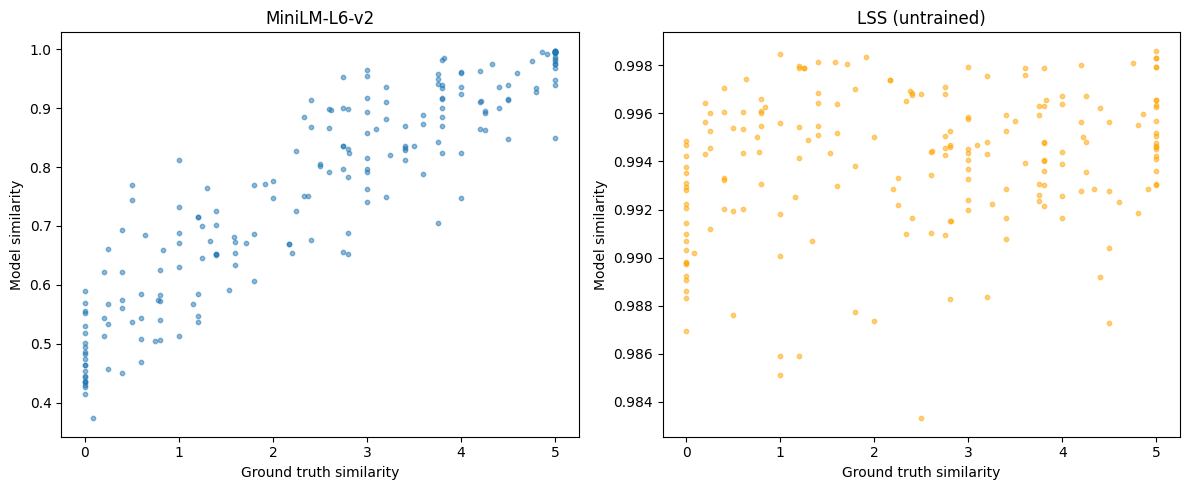

In [2]:
from benchmarks.compare import (
    load_minilm_v6, load_lss, encode_minilm, encode_lss,
    representation_similarity, benchmark_latency, model_size,
    sts_spearman
)
from datasets import load_dataset
import numpy as np
import matplotlib.pyplot as plt

minilm, minilm_tok = load_minilm_v6()
lss, lss_tok = load_lss()
enc_minilm = lambda t: encode_minilm(minilm, minilm_tok, t)
enc_lss = lambda t: encode_lss(lss, lss_tok, t)

sts = load_dataset('SetFit/stsb', split='validation')

# STS scatter plot
e1m = enc_minilm(list(sts['text1'])[:200])
e2m = enc_minilm(list(sts['text2'])[:200])
e1l = enc_lss(list(sts['text1'])[:200])
e2l = enc_lss(list(sts['text2'])[:200])

sim_m = (e1m * e2m).sum(axis=-1)
sim_l = (e1l * e2l).sum(axis=-1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.scatter(sts['label'][:200], sim_m, alpha=0.5, s=10)
ax1.set_title('MiniLM-L6-v2')
ax1.set_xlabel('Ground truth similarity')
ax1.set_ylabel('Model similarity')
ax2.scatter(sts['label'][:200], sim_l, alpha=0.5, s=10, color='orange')
ax2.set_title('LSS (untrained)')
ax2.set_xlabel('Ground truth similarity')
ax2.set_ylabel('Model similarity')
plt.tight_layout()
plt.show()

In [3]:
# Architecture comparison
config = __import__('lss_model.config', fromlist=['ModelConfig']).ModelConfig()

print('Architecture comparison:')
print(f'{"Config":<25} {"MiniLM-L6-v2":<20} {"LSS":<20}')
print('-' * 65)
print(f'{"hidden_size":<25} {384:<20} {config.hidden_size:<20}')
print(f'{"num_layers":<25} {6:<20} {config.num_hidden_layers:<20}')
print(f'{"num_heads":<25} {12:<20} {config.num_attention_heads:<20}')
print(f'{"intermediate_size":<25} {1536:<20} {config.intermediate_size:<20}')
print(f'{"max_seq_length":<25} {512:<20} {config.max_position_embeddings:<20}')
print(f'{"vocab_size":<25} {30522:<20} {config.vocab_size:<20}')
print(f'{"Params":<25} {22713216:<20} {22565376:<20}')

Architecture comparison:
Config                    MiniLM-L6-v2         LSS                 
-----------------------------------------------------------------
hidden_size               384                  384                 
num_layers                6                    6                   
num_heads                 12                   6                   
intermediate_size         1536                 1536                
max_seq_length            512                  512                 
vocab_size                30522                30522               
Params                    22713216             22565376            
